In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

In [7]:
import os

train_path = "model.h5"
test_path  = "model.h5"
cats_train_dir = os.path.join(train_path, "cats")
dogs_train_dir = os.path.join(train_path, "dogs")

cats_test_dir = os.path.join(test_path, "cats")
dogs_test_dir = os.path.join(test_path, "dogs")

print("Number of training cat images:", len(os.listdir(cats_train_dir)))
print("Number of training dog images:", len(os.listdir(dogs_train_dir)))
print("Number of testing cat images:", len(os.listdir(cats_test_dir)))
print("Number of testing dog images:", len(os.listdir(dogs_test_dir)))

Number of training cat images: 1012
Number of training dog images: 1013
Number of testing cat images: 1012
Number of testing dog images: 1013


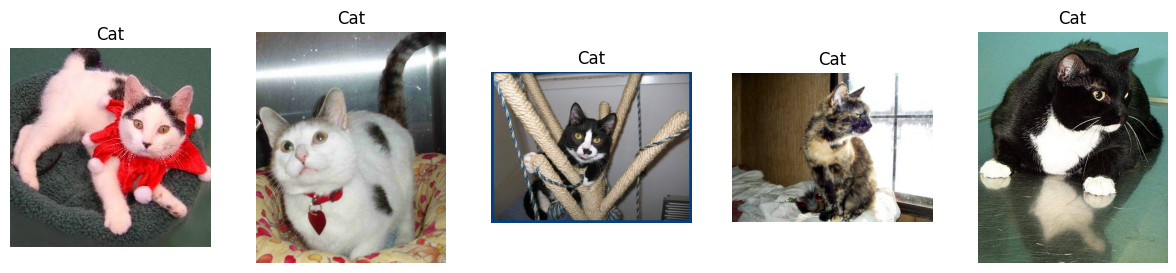

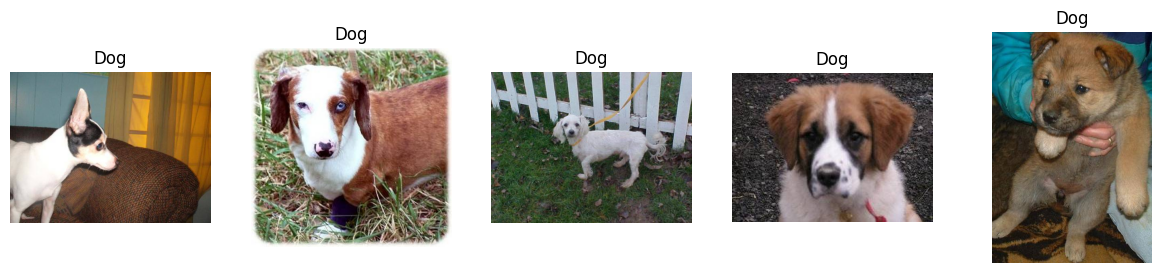

In [8]:
def show_samples(folder, label, n=5):
    plt.figure(figsize=(15,3))
    sample_files = random.sample(os.listdir(folder), n)
    for i, img_name in enumerate(sample_files):
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path)
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    plt.show()

show_samples(cats_train_dir, "Cat")
show_samples(dogs_train_dir, "Dog")

In [9]:
IMG_SIZE = 128
X = []
y = []

def is_image_file(filename):
    return filename.lower().endswith(('.png', '.jpg', '.jpeg'))

# Cats
for f in os.listdir(cats_train_dir):
    if is_image_file(f):
        img = Image.open(os.path.join(cats_train_dir, f)).resize((IMG_SIZE, IMG_SIZE))
        X.append(np.array(img))
        y.append(0)

# Dogs
for f in os.listdir(dogs_train_dir):
    if is_image_file(f):
        img = Image.open(os.path.join(dogs_train_dir, f)).resize((IMG_SIZE, IMG_SIZE))
        X.append(np.array(img))
        y.append(1)

X = np.array(X)
y = np.array(y)
print("Dataset shape:", X.shape, y.shape)

Dataset shape: (2023, 128, 128, 3) (2023,)


In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train / 255.0
X_val   = X_val / 255.0

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)

Train shape: (1618, 128, 128, 3) (1618,)
Validation shape: (405, 128, 128, 3) (405,)


Random Train Images:


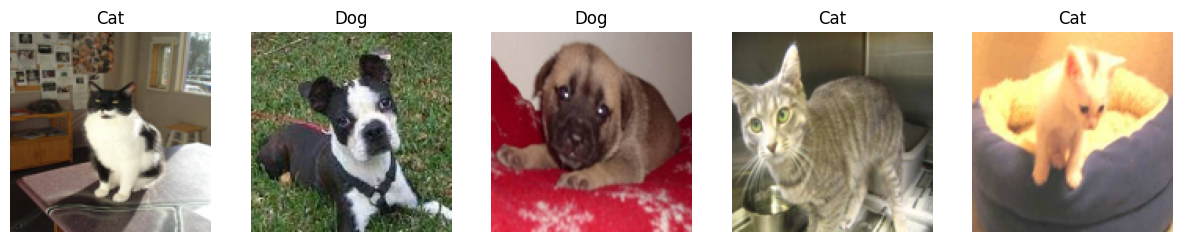

Random Validation Images:


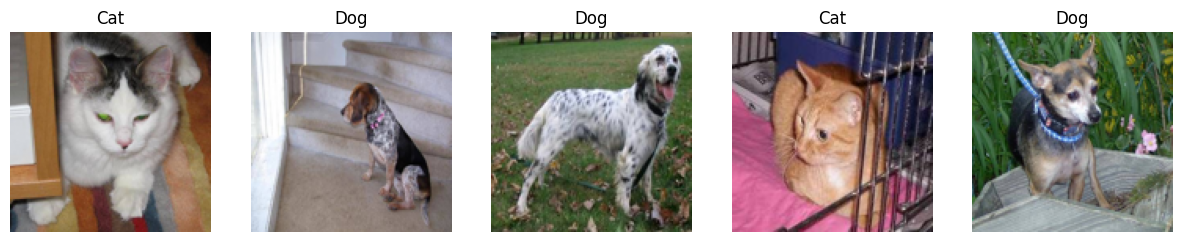

In [11]:
def show_random_batch(X, y, n=5):
    plt.figure(figsize=(15,3))
    idxs = random.sample(range(len(X)), n)
    for i, idx in enumerate(idxs):
        plt.subplot(1,n,i+1)
        plt.imshow(X[idx])
        plt.title("Cat" if y[idx]==0 else "Dog")
        plt.axis('off')
    plt.show()

print("Random Train Images:")
show_random_batch(X_train, y_train)

print("Random Validation Images:")
show_random_batch(X_val, y_val)


In [12]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)
train_generator = datagen.flow(X_train, y_train, batch_size=32)

In [13]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 63, 63, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 30, 30, 64)        0

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [16]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=60,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/60
51/51 [==============================] - 15s 268ms/step - loss: 0.7250 - accuracy: 0.4920 - val_loss: 0.6930 - val_accuracy: 0.5012
Epoch 2/60
51/51 [==============================] - 13s 256ms/step - loss: 0.6933 - accuracy: 0.4852 - val_loss: 0.6928 - val_accuracy: 0.5383
Epoch 3/60
51/51 [==============================] - 14s 273ms/step - loss: 0.6940 - accuracy: 0.5087 - val_loss: 0.6911 - val_accuracy: 0.5432
Epoch 4/60
51/51 [==============================] - 13s 262ms/step - loss: 0.6908 - accuracy: 0.5290 - val_loss: 0.6827 - val_accuracy: 0.5630
Epoch 5/60
51/51 [==============================] - 13s 257ms/step - loss: 0.6894 - accuracy: 0.5501 - val_loss: 0.6806 - val_accuracy: 0.5778
Epoch 6/60
51/51 [==============================] - 14s 266ms/step - loss: 0.6854 - accuracy: 0.5600 - val_loss: 0.6671 - val_accuracy: 0.6000
Epoch 7/60
51/51 [==============================] - 13s 258ms/step - loss: 0.6757 - accuracy: 0.5822 - val_loss: 0.6563 - val_accuracy: 0.6272

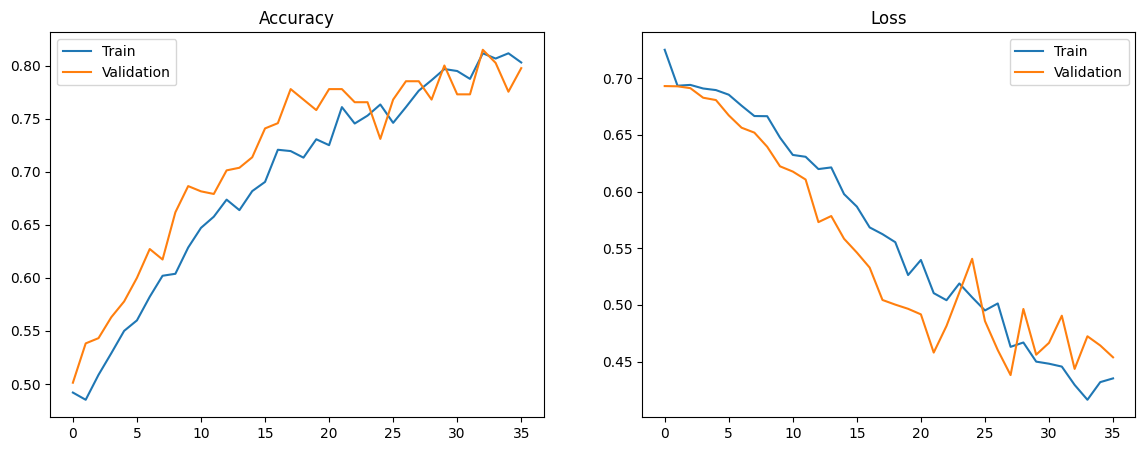

In [17]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

In [18]:
X_test, y_test = [], []
def is_image_file(filename):
    return filename.lower().endswith(('.png', '.jpg', '.jpeg'))


for f in os.listdir(cats_test_dir):
    if is_image_file(f):
      img = Image.open(os.path.join(cats_test_dir, f)).resize((IMG_SIZE, IMG_SIZE))
      X_test.append(np.array(img))
      y_test.append(0)

for f in os.listdir(dogs_test_dir):
   if is_image_file(f):
    img = Image.open(os.path.join(dogs_test_dir, f)).resize((IMG_SIZE, IMG_SIZE))
    X_test.append(np.array(img))
    y_test.append(1)

X_test = np.array(X_test) / 255.0
y_test = np.array(y_test)

print("Test Dataset shape:", X_test.shape, y_test.shape)

Test Dataset shape: (2023, 128, 128, 3) (2023,)


In [19]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

64/64 [==============================] - 3s 51ms/step - loss: 0.3862 - accuracy: 0.8309
Test Accuracy: 0.8309441208839417


In [20]:
def predict_multiple_images(n=5):
    indices = random.sample(range(len(X_test)), n)

    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        img = X_test[idx]
        true_label = "Cat" if y_test[idx] == 0 else "Dog"

        pred = model.predict(img.reshape(1, IMG_SIZE, IMG_SIZE, 3))
        pred_label = "Cat" if np.argmax(pred) == 0 else "Dog"

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"T:{true_label}\nP:{pred_label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

1/1 [==============================] - 0s 17ms/step


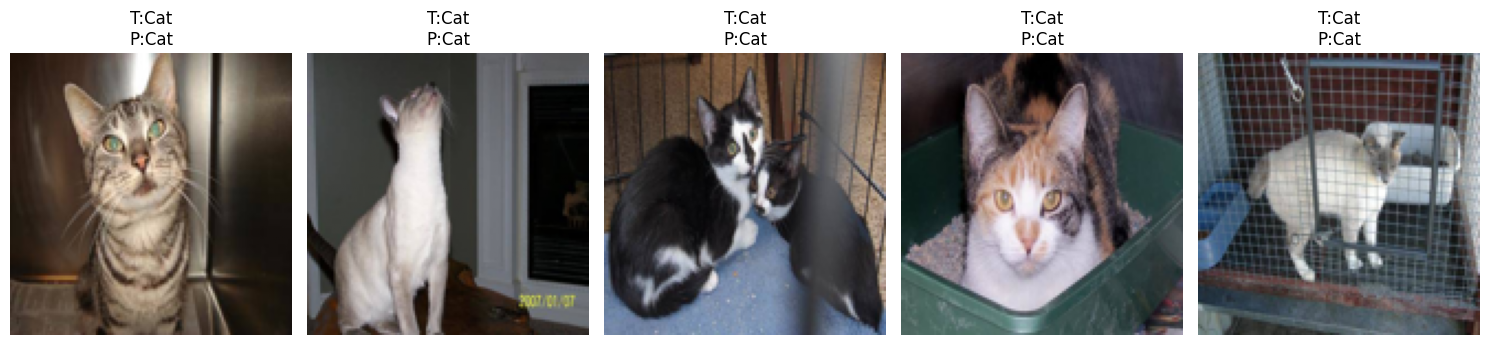

In [21]:
predict_multiple_images(5)

In [22]:
model.save("dogcat_model.keras")